In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
cwd = os.getcwd()

In [3]:
def read_vcf(filepath_or_buffer, usecols=None):
    with open(filepath_or_buffer) as vcf:
        while True:
            line = vcf.readline()
            if not line.startswith("##"):
                names = line[1:].split()
                break
        return pd.read_table(
             vcf, 
             sep="\t", 
             usecols=usecols, 
             header=None, 
             names=names
        )

In [4]:
folder = Path(cwd + "/../data/bcftools/sample_level")

# QC all samples

In [5]:
output_dict = {}

for f in folder.glob("bcftools_bulk_sample*.vcf"):
    # print(f.name[20:24])
    df = read_vcf(f)
    output_dict[str(f.name[20:24])] = len(df)

In [6]:
output_dict_filtered = {}

for f in folder.glob("bcftools_filtered_bulk_sample*.vcf"):
    # print(f.name[29:33])
    df = read_vcf(f)
    output_dict_filtered[str(f.name[29:33])] = len(df)

In [7]:
output_dict_diss_bulk = {}

for f in folder.glob("bcftools_diss_bulk_sample*.vcf"):
    # print(f.name[25:29])
    df = read_vcf(f)
    output_dict_diss_bulk[str(f.name[25:29])] = len(df)

In [8]:
output_dict_diss_bulk_filtered = {}

for f in folder.glob("bcftools_filtered_diss_bulk_sample*.vcf"):
    # print(f.name[34:38])
    df = read_vcf(f)
    output_dict_diss_bulk_filtered[str(f.name[34:38])] = len(df)

In [9]:
pre_filter_df = pd.DataFrame(
    {
        "sample id": output_dict.keys(),
        "pre-filtering length": output_dict.values()
    }
)
post_filter_df = pd.DataFrame(
    {
        "sample id": output_dict_filtered.keys(),
        "post-filtering length": output_dict_filtered.values()
    }
)
db_pre_filter_df = pd.DataFrame(
    {
        "sample id": output_dict_diss_bulk.keys(),
        "pre-filtering length": output_dict_diss_bulk.values()
    }
)
db_post_filter_df = pd.DataFrame(
    {
        "sample id": output_dict_diss_bulk_filtered.keys(),
        "post-filtering length": output_dict_diss_bulk_filtered.values()
    }
)

In [10]:
db_pre_filter_df.head()

,sample id,pre-filtering length
0,2401,467938
1,2364,570505
2,2416,233742
3,2238,713553
4,2407,480678


In [11]:
len(post_filter_df)

36

In [12]:
pre_filter_df["sample id"] = pre_filter_df["sample id"].astype(int)
post_filter_df["sample id"] = post_filter_df["sample id"].astype(int)
db_pre_filter_df["sample id"] = db_pre_filter_df["sample id"].astype(int)
db_post_filter_df["sample id"] = db_post_filter_df["sample id"].astype(int)

In [13]:
df = pd.merge(pre_filter_df, post_filter_df, on="sample id", how="outer")
db_df = pd.merge(db_pre_filter_df, db_post_filter_df, on="sample id", how="outer")

In [14]:
df["pct retained"] = df["post-filtering length"]/df["pre-filtering length"]
db_df["pct retained"] = db_df["post-filtering length"]/db_df["pre-filtering length"]

In [15]:
total_df = pd.merge(df, db_df, on="sample id", how="outer", suffixes=["_bulk", "_diss_bulk"])

In [16]:
total_df.sort_values(by="pct retained_diss_bulk")

,sample id,pre-filtering length_bulk,post-filtering length_bulk,pct retained_bulk,pre-filtering length_diss_bulk,post-filtering length_diss_bulk,pct retained_diss_bulk
33,2507,1706336,1441800,0.844968,13734.0,8408.0,0.612203
31,2477,1352375,1197821,0.885717,1506379.0,1081797.0,0.718144
16,2278,1463104,1301635,0.889639,895845.0,706053.0,0.788142
7,2209,1352410,1204596,0.890703,613999.0,496319.0,0.808338
11,2238,1479306,1315491,0.889262,713553.0,577845.0,0.809814
9,2221,1611420,1428560,0.886522,627377.0,508921.0,0.811188
20,2364,1388271,1251708,0.901631,570505.0,466445.0,0.817600
4,2129,956921,843363,0.881330,586049.0,479605.0,0.818370
12,2240,1468880,1303547,0.887443,419234.0,345789.0,0.824811
28,2455,1517478,1347526,0.888004,523170.0,432835.0,0.827331


/var/folders/yj/bt5772fx4p1cg9s9jbwzf0r00000gp/T/ipykernel_33623/3253248465.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = plt.cm.get_cmap('tab20', 20)


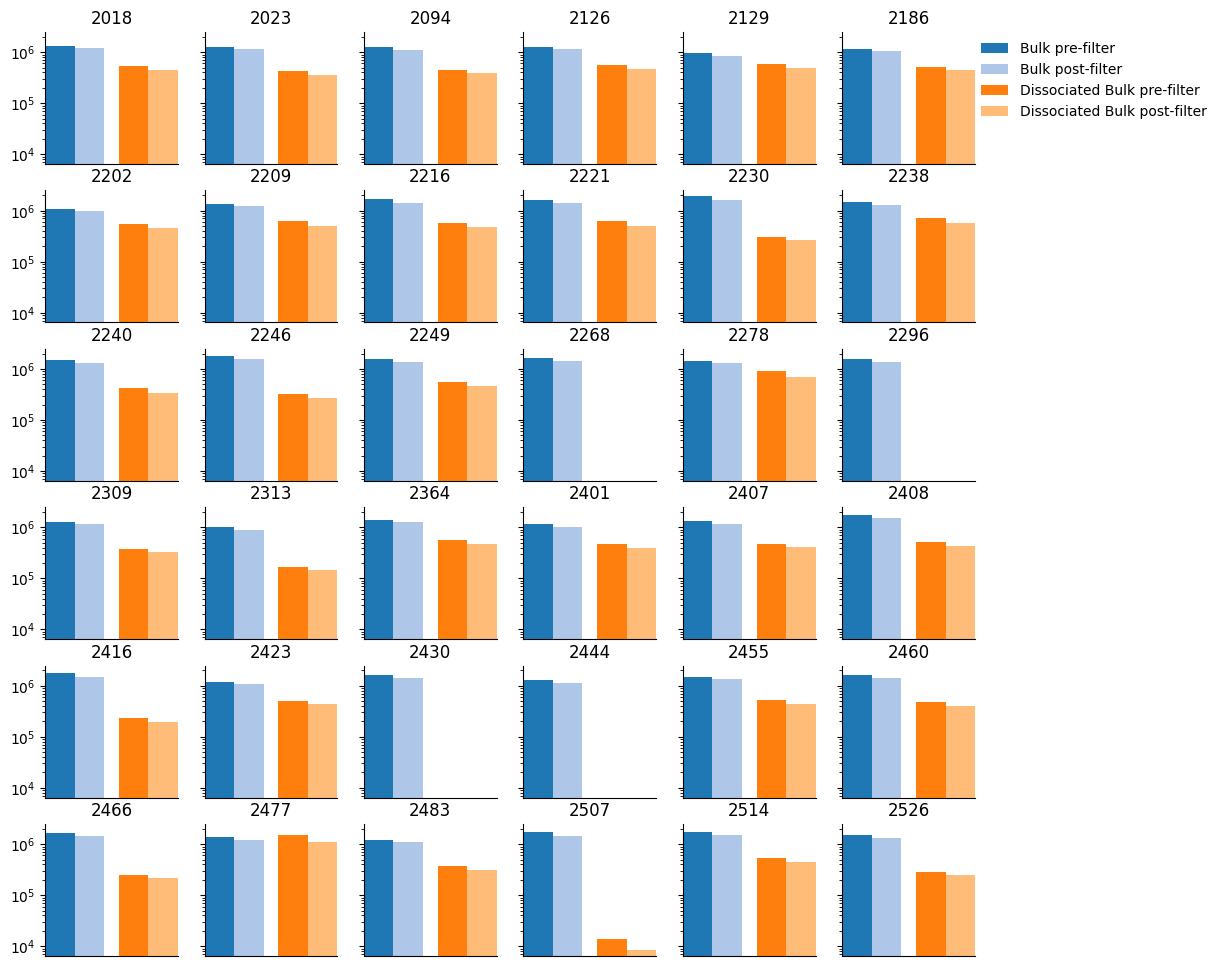

In [40]:
fig, ax = plt.subplots(6, 6, figsize=(12, 12), sharey=True)
tab20 = plt.cm.get_cmap('tab20', 20)
width = 0.25
offset = 0.5
for i in range(0, 6):
    for j in range(0, 6):
        k = (i * 6) + j
        # print((i, j), k)
        ax[i, j].bar([0], total_df["pre-filtering length_bulk"].iloc[k], width, label="Bulk pre-filter", color=tab20(0))
        ax[i, j].bar([0.25], total_df["post-filtering length_bulk"].iloc[k], width, label="Bulk post-filter", color=tab20(1/20))
        ax[i, j].bar([0.625], total_df["pre-filtering length_diss_bulk"].iloc[k], width, label="Dissociated Bulk pre-filter", color=tab20(2/20))
        ax[i, j].bar([0.875], total_df["post-filtering length_diss_bulk"].iloc[k], width, label="Dissociated Bulk post-filter", color=tab20(3/20))
        
        ax[i, j].spines['top'].set_visible(False)
        ax[i, j].spines['right'].set_visible(False)
        ax[i, j].set_title(total_df["sample id"].iloc[k])
        ax[i, j].set_xlim(-0.125, 1)
        ax[i, j].set_xticks([])
        ax[i, j].set_yscale("log")

ax[0, -1].legend(frameon=False, loc=(1, 0.3))

plt.show()

In [41]:
figname = "../figures/diss_vs_bulk_ref/number_of_variants_per_sample_barchart_log"
fig.savefig(figname + ".pdf", bbox_inches="tight")
fig.savefig(figname + ".png", bbox_inches="tight", dpi=300)

# Take a look at individual .vcfs

In [19]:
bulk_vcf_df = read_vcf(cwd + "/../data/bcftools/sample_level/bcftools_bulk_sample2094.vcf")

In [20]:
bulk_vcf_df.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,230509/2094
0,chr1,10560,.,C,G,175.5550,.,DP=62;VDB=2.68467e-08;SGB=7.12845;RPBZ=-2.7725...,GT:PL,"1/1:7,6,0"
1,chr1,10623,.,T,C,117.0780,.,DP=44;VDB=4.46641e-12;SGB=3.62545;RPBZ=-1.7165...,GT:PL,"1/1:4,3,0"
2,chr1,11868,.,C,T,57.2355,.,DP=8;VDB=0.749879;SGB=0.193064;RPBZ=-0.333333;...,GT:PL,"1/1:0,3,4"
3,chr1,14542,.,A,G,152.3750,.,DP=1396;VDB=5.46222e-13;SGB=-555.835;RPBZ=2.17...,GT:PL,"0/1:2,0,6"
4,chr1,14907,.,A,G,46.9347,.,DP=27;VDB=0.0934367;SGB=-0.285932;RPBZ=-0.2010...,GT:PL,"0/1:4,3,0"


In [21]:
bulk_filtered_vcf_df = read_vcf(cwd + "/../data/bcftools/sample_level/bcftools_filtered_bulk_sample2094.vcf")

In [22]:
len(bulk_filtered_vcf_df)

1128348

In [23]:
diss_bulk_vcf_df = read_vcf(cwd + "/../data/bcftools/sample_level/bcftools_diss_bulk_sample2094.vcf")

In [24]:
len(bulk_vcf_df)

1251102

In [25]:
test = bulk_filtered_vcf_df["INFO"].str.split(";", expand=True)

In [26]:
test.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,DP=62,VDB=2.68467e-08,SGB=7.12845,RPBZ=-2.77258,MQBZ=-2.01127,MQSBZ=1.38226,BQBZ=-0.754298,SCBZ=1.46361,FS=0,MQ0F=0.016129,AC=2,AN=2,"DP4=3,0,18,12",MQ=8,None,None,None
1,DP=44,VDB=4.46641e-12,SGB=3.62545,RPBZ=-1.71655,MQBZ=1.81319,MQSBZ=1.963,BQBZ=2.29692,SCBZ=-1.95722,FS=0,MQ0F=0.0227273,AC=2,AN=2,"DP4=1,0,13,9",MQ=4,None,None,None
2,DP=8,VDB=0.749879,SGB=0.193064,RPBZ=-0.333333,MQBZ=0.720082,MQSBZ=-0.62361,BQBZ=0,SCBZ=-1.09109,FS=0,MQ0F=0,AC=2,AN=2,"DP4=2,0,2,4",MQ=11,None,None,None
3,DP=1396,VDB=5.46222e-13,SGB=-555.835,RPBZ=2.17253,MQBZ=10.7138,MQSBZ=-11.6913,BQBZ=-2.77349,SCBZ=-1.07529,FS=0,MQ0F=0.0465616,AC=1,AN=2,"DP4=595,373,153,18",MQ=6,None,None,None
4,DP=27,VDB=0.0934367,SGB=-0.285932,RPBZ=-0.201054,MQBZ=0.845403,MQSBZ=-2.59257,BQBZ=0.77808,SCBZ=1.54316,FS=0,MQ0F=0,AC=1,AN=2,"DP4=5,12,5,5",MQ=11,None,None,None


In [27]:
len(test)

1128348

In [28]:
test["DP"] = test[test[0].str.contains("DP=")][0].str.replace("DP=", "")

In [29]:
test["DP1"] = test[test[3].str.contains("DP=")][3].str.replace("DP=", "")

In [30]:
test["DP"] = test["DP"].fillna(test["DP1"]).astype(int)

In [31]:
test = test.drop(columns=["DP1"])

In [32]:
test

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,DP
0,DP=62,VDB=2.68467e-08,SGB=7.12845,RPBZ=-2.77258,MQBZ=-2.01127,MQSBZ=1.38226,BQBZ=-0.754298,SCBZ=1.46361,FS=0,MQ0F=0.016129,AC=2,AN=2,"DP4=3,0,18,12",MQ=8,None,None,None,62
1,DP=44,VDB=4.46641e-12,SGB=3.62545,RPBZ=-1.71655,MQBZ=1.81319,MQSBZ=1.963,BQBZ=2.29692,SCBZ=-1.95722,FS=0,MQ0F=0.0227273,AC=2,AN=2,"DP4=1,0,13,9",MQ=4,None,None,None,44
2,DP=8,VDB=0.749879,SGB=0.193064,RPBZ=-0.333333,MQBZ=0.720082,MQSBZ=-0.62361,BQBZ=0,SCBZ=-1.09109,FS=0,MQ0F=0,AC=2,AN=2,"DP4=2,0,2,4",MQ=11,None,None,None,8
3,DP=1396,VDB=5.46222e-13,SGB=-555.835,RPBZ=2.17253,MQBZ=10.7138,MQSBZ=-11.6913,BQBZ=-2.77349,SCBZ=-1.07529,FS=0,MQ0F=0.0465616,AC=1,AN=2,"DP4=595,373,153,18",MQ=6,None,None,None,1396
4,DP=27,VDB=0.0934367,SGB=-0.285932,RPBZ=-0.201054,MQBZ=0.845403,MQSBZ=-2.59257,BQBZ=0.77808,SCBZ=1.54316,FS=0,MQ0F=0,AC=1,AN=2,"DP4=5,12,5,5",MQ=11,None,None,None,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128343,DP=81,VDB=0.000548386,SGB=41.7003,RPBZ=2.76613,MQBZ=-0.477998,MQSBZ=-1.86702,BQBZ=0.341442,SCBZ=0.811266,FS=0,MQ0F=0.037037,AC=1,AN=2,"DP4=5,19,12,37",MQ=13,None,None,None,81
1128344,DP=128,VDB=0.441104,SGB=83.8573,RPBZ=0.599212,MQBZ=-2.32366,MQSBZ=-1.70651,BQBZ=-2.62237,SCBZ=-3.94551,FS=0,MQ0F=0.015625,AC=2,AN=2,"DP4=10,9,15,79",MQ=12,None,None,None,128
1128345,DP=71,VDB=0.994853,SGB=11.7734,RPBZ=1.17823,MQBZ=-1.40166,MQSBZ=1.24785,BQBZ=-0.591957,SCBZ=-1.104,FS=0,MQ0F=0,AC=2,AN=2,"DP4=1,6,21,18",MQ=16,None,None,None,71
1128346,DP=933,VDB=0.204832,SGB=-37.2669,RPBZ=-0.730913,MQBZ=0.435465,MQSBZ=-11.1267,BQBZ=0.252255,SCBZ=0.120871,FS=0,MQ0F=0.00321543,AC=1,AN=2,"DP4=284,314,98,96",MQ=16,None,None,None,933


In [33]:
np.mean(test["DP"])

np.float64(267.84481826528696)

In [34]:
len(test[test["DP"]<30])/len(bulk_vcf_df)

0.10493229169164464

In [35]:
len(test[test["DP"]>500])/len(bulk_vcf_df)

0.11456539914411455